In [1]:
import pywt
import numpy as np
import pandas as pd
import os

In [2]:
os.chdir('..')

In [3]:
df = pd.read_csv('data/BTCUSD_2023_2024.csv', index_col='Gmt time')
df = df[-4050:]

In [4]:
close = df['Close']

# V1

In [25]:
coeff1 = pywt.wavedec(close, 'db4', level=4)

In [20]:
close_pad = np.pad(close, pad_width=100, mode='edge')

In [23]:
coeff2 = pywt.wavedec(close_pad, 'db4', level=4)

In [28]:
coeff2[0].shape

(272,)

In [29]:
coeff1[0].shape

(259,)

In [26]:
if coeff1==coeff2:
    print('Equality')
else:
    print('No equality')

ValueError: operands could not be broadcast together with shapes (259,) (272,) 

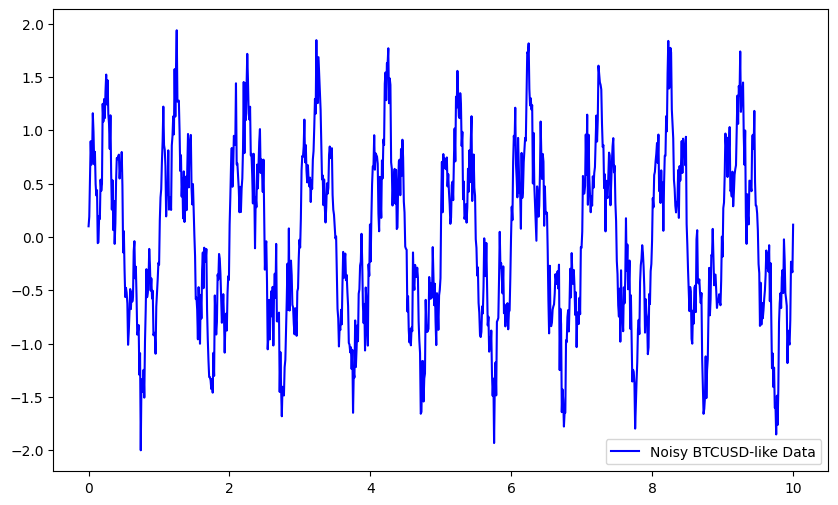

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic BTCUSD-like data
np.random.seed(42)
t = np.linspace(0, 10, 1000)
signal = np.sin(2 * np.pi * t) + 0.5 * np.sin(10 * np.pi * t)  # Smooth trend + high-frequency component
noise = 0.2 * np.random.randn(1000)  # Add Gaussian noise
data = signal + noise

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(t, data, label="Noisy BTCUSD-like Data", color='blue')
plt.legend()
plt.show()

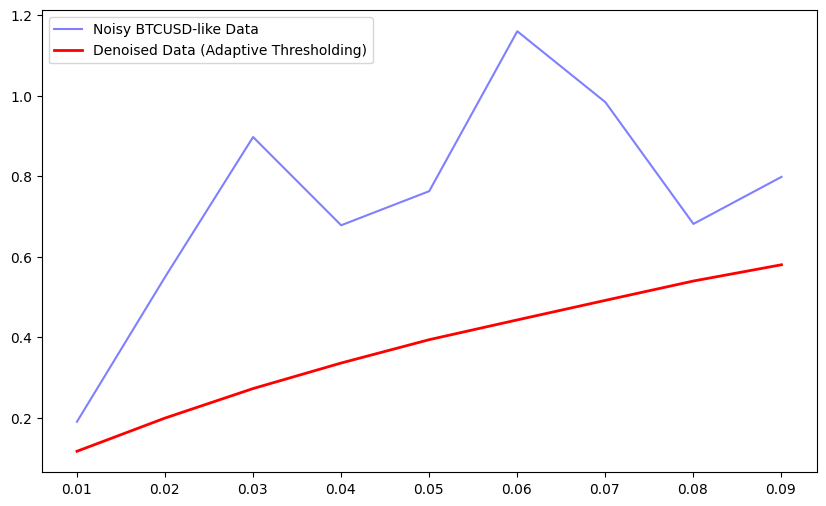

In [70]:
import pywt

def adaptive_thresholding(data, wavelet='db4', level=4, threshold_mode='soft'):
    # Decompose signal using Wavelet Transform
    coeff = pywt.wavedec(data, wavelet, mode="per", level=level)
    
    # Estimate the noise level
    sigma = (1 / 0.6745) * np.median(np.abs(coeff[-level] - np.median(coeff[-level])))
    
    # Calculate level-dependent thresholds
    thresholds = [sigma * np.sqrt(2 * np.log(len(data))) / (2 ** (i + 1)) for i in range(level)]
    
    # Apply thresholding to detail coefficients
    coeff[1:] = [pywt.threshold(i, value=thresh, mode=threshold_mode) for i, thresh in zip(coeff[1:], thresholds)]
    
    # Reconstruct the denoised signal
    denoised_data = pywt.waverec(coeff, wavelet, mode='per')
    
    return denoised_data

# Apply adaptive thresholding
denoised_data = adaptive_thresholding(data)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t[1:10], data[1:10], label="Noisy BTCUSD-like Data", color='blue', alpha=0.5)
plt.plot(t[1:10], denoised_data[1:10], label="Denoised Data (Adaptive Thresholding)", color='red', linewidth=2)
plt.legend()
plt.show()

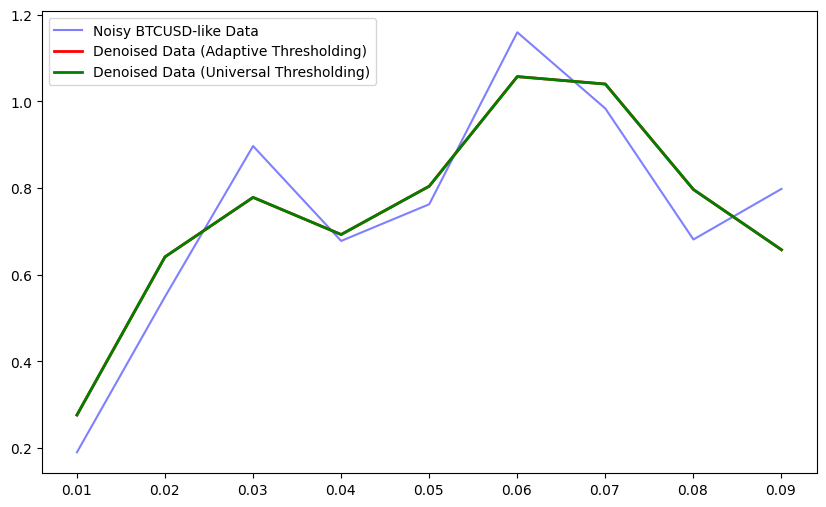

In [69]:
def universal_thresholding(data, wavelet='db4', level=1, threshold_mode='hard'):
    # Decompose signal using Wavelet Transform
    coeff = pywt.wavedec(data, wavelet, mode="per", level=level)
    
    # Estimate the noise level
    sigma = (1 / 0.6745) * np.median(np.abs(coeff[-level] - np.median(coeff[-level])))
    
    # Calculate the universal threshold
    uthresh = sigma * np.sqrt(2 * np.log(len(data)))
    
    # Apply thresholding to detail coefficients
    coeff[1:] = [pywt.threshold(i, value=uthresh, mode=threshold_mode) for i in coeff[1:]]
    
    # Reconstruct the denoised signal
    denoised_data = pywt.waverec(coeff, wavelet, mode='per')
    
    return denoised_data

# Apply universal thresholding
denoised_data_universal = universal_thresholding(data)

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t[1:10], data[1:10], label="Noisy BTCUSD-like Data", color='blue', alpha=0.5)
plt.plot(t[1:10], denoised_data[1:10], label="Denoised Data (Adaptive Thresholding)", color='red', linewidth=2)
plt.plot(t[1:10], denoised_data_universal[1:10], label="Denoised Data (Universal Thresholding)", color='green', linewidth=2)
plt.legend()
plt.show()

In [2]:
import os
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\denoise'

In [1]:
from src.genetic import backtest

# V2

In [79]:

import pywt
import numpy as np

# -------------------------------------------------------------------------------------------
# Wavelet denoising
#
# Reference: https://doi.org/10.1002/for.3071
# (the idea of the wavelet denoising and some parameters are taken from this paper)
# -------------------------------------------------------------------------------------------

# Function for padding the data
def pad_data(data, pad_width, mode='edge'):
    return np.pad(data, pad_width, mode=mode)

# Wavelet denoising function with parameterisation for wavelet type and decomposition level
def wavelet_denoising(data, wavelet='db4', level=1):
    # Padding with a width of 100
    padded_data = pad_data(data, pad_width=100, mode='edge')
    # Decompose signal using Wavelet Transform
    coeff = pywt.wavedec(padded_data, wavelet, mode="per", level=level)
    coeff_out = coeff.copy()
    # Estimate the noise level
    sigma = (1 / 0.6745) * np.median(np.abs(coeff[-level] - np.median(coeff[-level])))
    # Calculate the universal threshold
    uthresh = sigma * np.sqrt(2 * np.log(len(padded_data)))
    # uthresh = [sigma * np.sqrt(2 * np.log(len(padded_data))) / (2 ** (i + 1)) for i in range(level)]
    # Apply soft thresholding to detail coefficients
    coeff[1:] = [pywt.threshold(i, value=uthresh, mode='hard') for i in coeff[1:]]
    # coeff[1:] = [pywt.threshold(i, value=thresh, mode='soft') for i, thresh in zip(coeff[1:], uthresh)]
    # Set high-frequency coefficients to zero ]
    coeff[-level] = np.zeros_like(coeff[-level])
    # Reconstruct the denoised signal
    denoised_data = pywt.waverec(coeff, wavelet, mode='per')
    # Remove the padding
    denoised_data = denoised_data[100:-100]  # Adjust this if necessary

    # Handle edge effects
    if len(denoised_data) > len(data):
        denoised_data = denoised_data[:len(data)]
    elif len(denoised_data) < len(data):
        denoised_data = np.pad(denoised_data, (0, len(data) - len(denoised_data)), 'edge')

    return denoised_data, coeff_out, sigma, uthresh, coeff


In [80]:
denoised_data_1, coeff_out_1, sigma_1, uthresh_1, coeff_1 = wavelet_denoising(close, level=1)
denoised_data_2, coeff_out_2, sigma_2, uthresh_2, coeff_2 = wavelet_denoising(close, level=2)
denoised_data_3, coeff_out_3, sigma_3, uthresh_3, coeff_3 = wavelet_denoising(close, level=3)

In [77]:
np.count_nonzero(coeff_1[1])

37

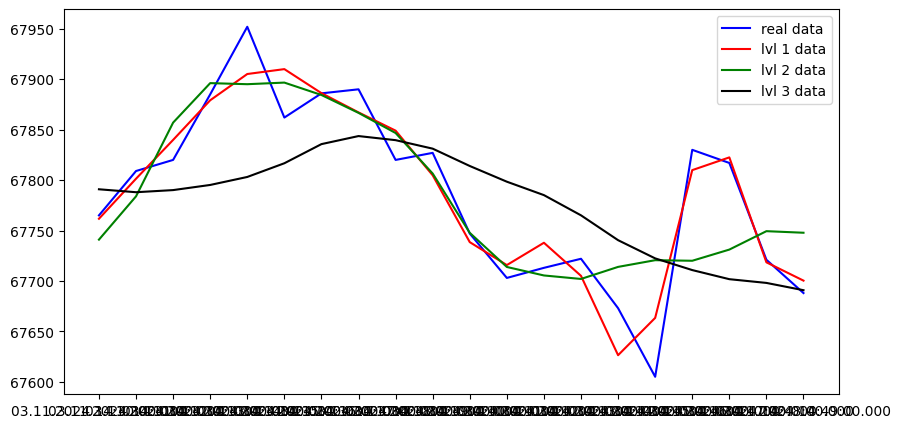

In [81]:
fig, axes = plt.subplots(1,1, figsize=(10,5))

axes.plot(close[600:620], color='blue', label='real data')
axes.plot(denoised_data_1[600:620], color='red', label='lvl 1 data')
axes.plot(denoised_data_2[600:620], color='green', label='lvl 2 data')
axes.plot(denoised_data_3[600:620], color='black', label='lvl 3 data')

plt.legend()

In [34]:
coeff_3[-4]

array([196105.84577236, 196222.62309733, 194172.05622189, 193846.25299448,
       193846.25299448, 193846.25299448, 193846.25299448, 193846.25299448,
       193846.25299448, 193846.25299448, 193846.25799285, 193845.96904583,
       193847.94817829, 193839.35783422, 193874.05113795, 194074.73212105,
       193797.74314379, 193836.95100091, 193844.61165558, 194120.50679213,
       193972.40012527, 193692.01510784, 193552.59171428, 193719.5688404 ,
       193646.43825429, 193485.71952927, 193569.06866633, 193406.54860863,
       193623.73904225, 193604.65444822, 193586.50107308, 194144.65123802,
       193996.32767855, 193854.18706754, 194095.41271556, 194060.61378583,
       193707.07874176, 193442.41397355, 193410.76926899, 193400.9916166 ,
       193325.90897295, 193304.65413273, 193185.92243533, 193160.27846073,
       193274.61013008, 193436.37178464, 193708.73948892, 193746.99520136,
       193507.7579947 , 193573.75599271, 193578.85655789, 193433.90926054,
       193242.837396  , 1

In [55]:
np.count_nonzero(coeff_3[-2])

1

In [41]:
coeff_2[-1]

array([-0.        , -0.        ,  0.        , ..., -0.        ,
       49.60376165,  0.        ])

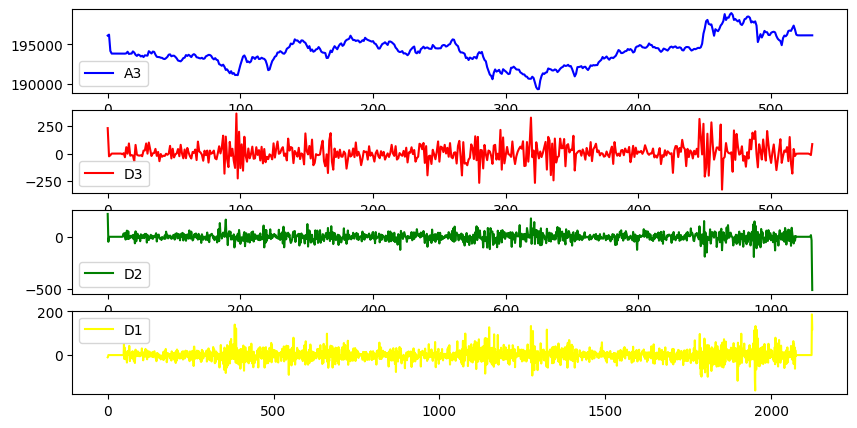

In [33]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4,1, figsize=(10,5))

axes[0].plot(coeff_out_3[0], color = 'blue', label = 'A3')
axes[1].plot(coeff_out_3[1], color = 'red', label = 'D3')
axes[2].plot(coeff_out_3[2], color = 'green', label = 'D2')
axes[3].plot(coeff_out_3[3], color = 'yellow', label = 'D1')


axes[0].legend()
axes[1].legend()
axes[2].legend()
axes[3].legend()

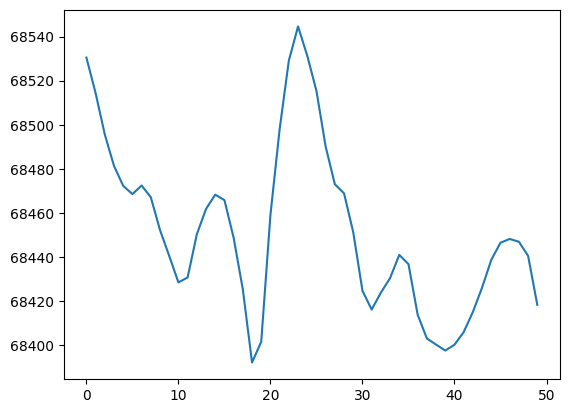

In [28]:
plt.plot(denoised_data[50:100])
plt.plot()

[]

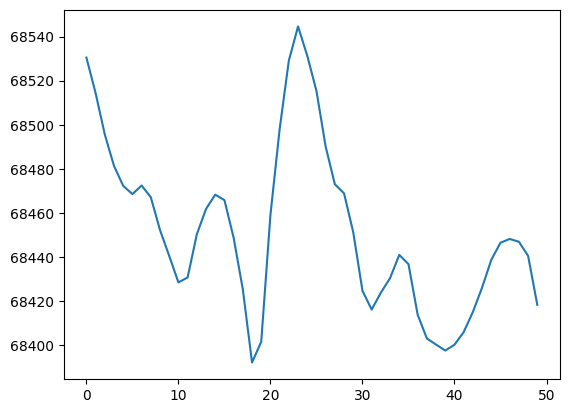

In [51]:
plt.plot(denoised_data[50:100])
plt.plot()

In [14]:
low_freq = coeff_out[0]
high_freq = coeff_out[1]


In [ ]:
low_freq = low_freq[100:]

In [21]:
sigma

18.362401701657806

In [24]:
uthresh

75.06011798612772